In [2]:
import pandas as pd

data = pd.read_csv("UVCE_Assignment.csv")

print(data.head())
print("Number of rows:", len(data))
print("Columns:", data.columns.tolist())

            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340
Number of rows: 1500
Columns: ['x', 'y']


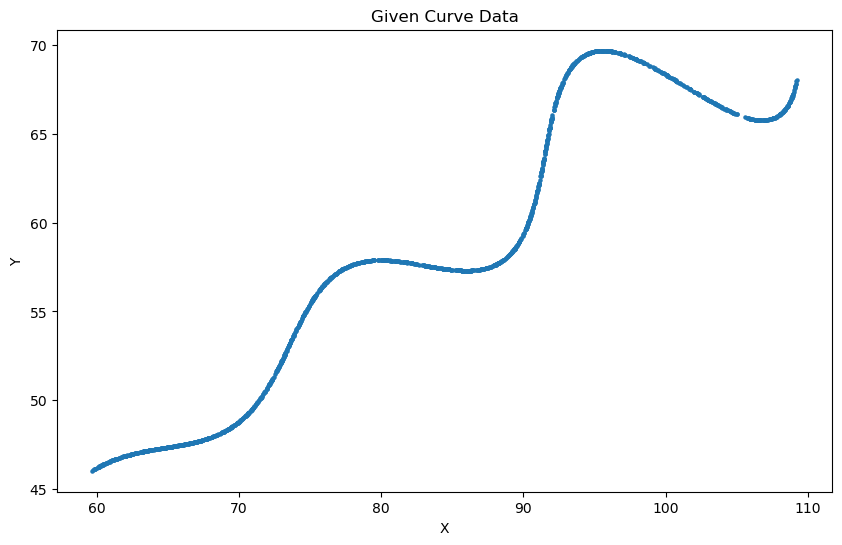

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(data["x"], data["y"], s=5)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Given Curve Data")

plt.show()

In [4]:
import numpy as np
from scipy.optimize import differential_evolution


x_data = data["x"].values
y_data = data["y"].values


t = np.linspace(6, 60, len(data))



def curve(parameters):

    theta, M, X = parameters

   
    theta = np.radians(theta)

    x = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    )

    return x, y



def error(parameters):

    x_pred, y_pred = curve(parameters)

    
    total_error = np.sum(
        np.abs(x_data - x_pred) +
        np.abs(y_data - y_pred)
    )

    return total_error



bounds = [
    (0, 50),      
    (-0.05, 0.05),
    (0, 100)      
]



result = differential_evolution(
    error,
    bounds,
    seed=42,
    tol=1e-10
)



theta, M, X = result.x

print("Best values found:")
print("Theta =", theta)
print("M     =", M)
print("X     =", X)
print("Error =", result.fun)

Best values found:
Theta = 28.11842374136321
M     = 0.02138895359862982
X     = 54.899228636444285
Error = 37865.09383874647


In [5]:
import numpy as np
from scipy.optimize import differential_evolution


sorted_data = data.sort_values("x")

x_data = sorted_data["x"].values
y_data = sorted_data["y"].values


t = np.linspace(6, 60, len(data))


def curve(parameters):

    theta, M, X = parameters

    
    theta = np.radians(theta)

    x = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t))
        * np.sin(0.3 * t)
        * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t))
        * np.sin(0.3 * t)
        * np.cos(theta)
    )

    return x, y


def error(parameters):

    x_pred, y_pred = curve(parameters)

    return np.mean(
        np.abs(x_data - x_pred)
        + np.abs(y_data - y_pred)
    )


bounds = [
    (0, 50),        # theta
    (-0.05, 0.05),  # M
    (0, 100)        # X
]


result = differential_evolution(
    error,
    bounds,
    seed=42,
    tol=1e-10
)


theta, M, X = result.x

print("Best values found:")
print("Theta =", theta)
print("M     =", M)
print("X     =", X)
print("Error =", result.fun)

Best values found:
Theta = 30.04363630100933
M     = 0.029990545253682784
X     = 55.015520867799125
Error = 0.30229126685682867


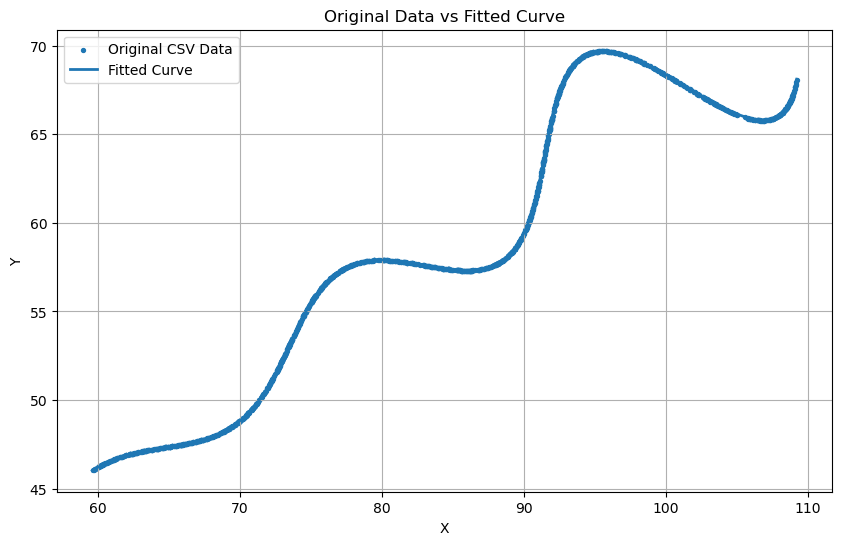

In [6]:

x_pred, y_pred = curve([theta, M, X])

plt.figure(figsize=(10, 6))


plt.scatter(
    x_data,
    y_data,
    s=8,
    label="Original CSV Data"
)


plt.plot(
    x_pred,
    y_pred,
    linewidth=2,
    label="Fitted Curve"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Original Data vs Fitted Curve")
plt.legend()
plt.grid(True)

plt.show()